<a href="https://colab.research.google.com/github/muajnstu/Plan_Crash_Prediction_-_Topic_Modelling/blob/main/D3_Implementation_with_already_balanced_distribution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Pipeline Overview

1. Install & Import
2. Global Constants & All Function Definitions
3. Data Loading & Preprocessing
4. TF-IDF Vectorisation
5. Label Encoding
6. ONE split, shared by ALL models
7. Classic ML — Train
8. Deep Learning — LSTM / GRU / CNN / BiLSTM
9. Transformer — BERT / RoBERTa / DistilBERT / ALBERT
10. Results — Compare & Summarise

**Install Dependencies**

In [ ]:
# Run once in Colab; restart runtime after installation
!pip install -q imbalanced-learn xgboost lightgbm transformers torch scikit-learn

**Imports**

In [ ]:
import warnings, time, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from collections import Counter
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay,
    silhouette_score
)
from sklearn.linear_model import LogisticRegression, RidgeClassifier, Perceptron, SGDClassifier
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, ExtraTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier,
    BaggingClassifier, ExtraTreesClassifier
)
from sklearn.svm import SVC, LinearSVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, GRU, Dense, Conv1D, GlobalMaxPooling1D, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from scipy.sparse import issparse
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

print('All imports successful.')

All imports successful.


**Global Constants**

In [ ]:
# ── Reproducibility
RANDOM_STATE   = 42

# ── TF-IDF / LSA  (Classic ML features)
TFIDF_MAX_FEAT = 10_000
LSA_COMPONENTS = 100

# ── Train / val / test split
TEST_SIZE      = 0.20
VAL_SIZE       = 0.10

# ── Deep Learning
MAX_WORDS      = 10_000      # Tokenizer vocabulary size
MAX_LEN        = 100         # Padded sequence length
EMBED_DIM      = 100         # Embedding dimension
DL_EPOCHS      = 5
DL_BATCH_SIZE  = 32

# ── Transformer
TRANSFORMER_MAX_LEN   = 128
TRANSFORMER_EPOCHS    = 3
TRANSFORMER_BATCH     = 8
TRANSFORMER_LR        = 2e-5

# ── Label map  —
LABEL_MAP = {}

# ── Classifiers that require scaled input
NEEDS_SCALE = {
    'LogisticRegression', 'RidgeClassifier', 'SGDClassifier', 'Perceptron',
    'GaussianNB', 'BernoulliNB', 'KNeighborsClassifier',
    'LinearDiscriminantAnalysis', 'QuadraticDiscriminantAnalysis',
    'LinearSVC', 'SVC_RBF', 'MLPClassifier',
}


**All Function Definitions**
> Every helper used downstream is defined here.
> Clustering helpers are omitted — not needed for an already-balanced dataset.


In [ ]:

# TEXT PREPROCESSING

_stop_words  = set(stopwords.words('english'))
_lemmatizer  = WordNetLemmatizer()

def clean_text(text: str) -> str:
    """Lowercase → strip non-alpha → remove stopwords → lemmatise."""
    text   = str(text).lower()
    text   = re.sub(r'[^a-z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [_lemmatizer.lemmatize(w) for w in tokens if w not in _stop_words]
    return ' '.join(tokens)

# TRAIN / TEST SPLIT & SCALING


def split_and_scale(
    X: np.ndarray,
    y: np.ndarray,
    test_size: float = TEST_SIZE,
    val_size: float  = VAL_SIZE
):
    """
    Stratified 80 / 10 / 10 split (train / val / test) + StandardScaler.

    Returns
    -------
    X_train, X_val, X_test       : raw (unscaled) splits
    X_train_sc, X_val_sc, X_test_sc : scaled splits
    y_train, y_val, y_test       : label arrays
    scaler                       : fitted StandardScaler
    """
    # First split: train+val vs test
    X_tv, X_test, y_tv, y_test = train_test_split(
        X, y, test_size=test_size, random_state=RANDOM_STATE, stratify=y
    )
    # Second split: train vs val
    val_frac = val_size / (1.0 - test_size)          # relative fraction
    X_train, X_val, y_train, y_val = train_test_split(
        X_tv, y_tv, test_size=val_frac, random_state=RANDOM_STATE, stratify=y_tv
    )

    # Fix: Pass with_mean=False to StandardScaler for sparse matrices
    scaler      = StandardScaler(with_mean=False)
    X_train_sc  = scaler.fit_transform(X_train)
    X_val_sc    = scaler.transform(X_val)
    X_test_sc   = scaler.transform(X_test)

    print(f'Train : {X_train_sc.shape} | class dist: {Counter(y_train)}')
    print(f'Val   : {X_val_sc.shape}   | class dist: {Counter(y_val)}')
    print(f'Test  : {X_test_sc.shape}  | class dist: {Counter(y_test)}')

    return (X_train, X_val, X_test,
            X_train_sc, X_val_sc, X_test_sc,
            y_train, y_val, y_test,
            scaler)


# METRICS

def calculate_metrics(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    y_proba: np.ndarray | None,
    model_name: str
) -> dict:
    """
    Compute accuracy, precision, recall, weighted-F1, and macro-AUC.
    y_proba : (n_samples, n_classes) probability matrix, or None to skip AUC.

    Returns a dict suitable for pd.DataFrame.from_dict(orient='index').
    """
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    if y_proba is not None:
        try:
            auc = roc_auc_score(y_true, y_proba, multi_class='ovr', average='macro')
        except ValueError:
            auc = float('nan')
    else:
        auc = float('nan')

    return {
        'Model'    : model_name,
        'Accuracy' : round(acc,  4),
        'Precision': round(prec, 4),
        'Recall'   : round(rec,  4),
        'F1'       : round(f1,   4),
        'AUC'      : round(auc,  4),
    }


# CLASSIC ML

def build_classifiers() -> dict:
    """Return a fresh dict of (name → unfitted classifier)."""
    return {
        # Linear
        'LogisticRegression'           : LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        'RidgeClassifier'              : RidgeClassifier(),
        'SGDClassifier'                : SGDClassifier(max_iter=1000, random_state=RANDOM_STATE),
        'Perceptron'                   : Perceptron(max_iter=1000, random_state=RANDOM_STATE),
        # Naive Bayes
        'GaussianNB'                   : GaussianNB(),
        'BernoulliNB'                  : BernoulliNB(),
        # Distance
        'KNeighborsClassifier'         : KNeighborsClassifier(n_neighbors=5),
        # Discriminant
        'LinearDiscriminantAnalysis'   : LinearDiscriminantAnalysis(),
        'QuadraticDiscriminantAnalysis': QuadraticDiscriminantAnalysis(reg_param=0.1),
        # Tree
        'DecisionTreeClassifier'       : DecisionTreeClassifier(random_state=RANDOM_STATE),
        # Ensemble
        'RandomForestClassifier'       : RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
        'ExtraTreesClassifier'         : ExtraTreesClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
        'AdaBoostClassifier'           : AdaBoostClassifier(n_estimators=200, random_state=RANDOM_STATE),
        'GradientBoostingClassifier'   : GradientBoostingClassifier(n_estimators=200, random_state=RANDOM_STATE),
        'BaggingClassifier'            : BaggingClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
        # SVM
        'LinearSVC'                    : LinearSVC(max_iter=2000, random_state=RANDOM_STATE),
        'SVC_RBF'                      : SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE),
        # Gradient boosting (external)
        'XGBClassifier'                : XGBClassifier(n_estimators=200, random_state=RANDOM_STATE, eval_metric='mlogloss', verbosity=0),
        'LGBMClassifier'               : LGBMClassifier(n_estimators=200, random_state=RANDOM_STATE, verbosity=-1),
        # Neural
        'MLPClassifier'                : MLPClassifier(hidden_layer_sizes=(256, 128), max_iter=300, random_state=RANDOM_STATE),
    }


def run_classic_ml(
    X_train: np.ndarray, X_test: np.ndarray,
    X_train_sc: np.ndarray, X_test_sc: np.ndarray,
    y_train: np.ndarray, y_test: np.ndarray
) -> dict:
    """
    Train all classic ML classifiers and collect metrics.
    Prints a one-line summary per model; full results returned as a dict.

    Returns
    -------
    dict  {model_name: metrics_dict}
    """
    classifiers = build_classifiers()
    results     = {}

    print(f'{"Model":<36}  {"Acc":>6}  {"F1":>6}  {"AUC":>6}  {"Time":>6}')
    print('-' * 65)

    for name, clf in classifiers.items():
        Xtr = X_train_sc if name in NEEDS_SCALE else X_train
        Xte = X_test_sc  if name in NEEDS_SCALE else X_test

        t0 = time.time()
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            clf.fit(Xtr, y_train)
            y_pred = clf.predict(Xte)
        elapsed = time.time() - t0

        # Probability matrix for AUC (not all classifiers support predict_proba)
        y_proba = None
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            if hasattr(clf, 'predict_proba'):
                y_proba = clf.predict_proba(Xte)
            elif hasattr(clf, 'decision_function'):
                df = clf.decision_function(Xte)
                # Convert decision scores to pseudo-probabilities via softmax
                e  = np.exp(df - df.max(axis=1, keepdims=True))
                y_proba = e / e.sum(axis=1, keepdims=True)

        m = calculate_metrics(y_test, y_pred, y_proba, name)
        m['Time(s)'] = round(elapsed, 2)
        results[name] = m

        print(f'{name:<36}  {m["Accuracy"]:>6.4f}  {m["F1"]:>6.4f}  '
              f'{m["AUC"]:>6.4f}  {elapsed:>5.1f}s')

    return results

# DEEP LEARNING  (Keras)

def prepare_dl_data(
    X_train_raw, X_val_raw, X_test_raw,
    y_train: np.ndarray, y_val: np.ndarray, y_test: np.ndarray
):
    """
    Tokenise + pad text sequences for Keras DL models.
    X_* inputs should be arrays / Series of raw (pre-cleaned) text strings.

    Returns
    -------
    X_train_seq, X_val_seq, X_test_seq  : padded integer sequences
    y_train, y_val, y_test              : numpy label arrays
    tokenizer                           : fitted Keras Tokenizer
    """
    tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
    tokenizer.fit_on_texts(X_train_raw)

    def _seq(X):
        return pad_sequences(tokenizer.texts_to_sequences(X), maxlen=MAX_LEN)

    X_train_seq = _seq(X_train_raw)
    X_val_seq   = _seq(X_val_raw)
    X_test_seq  = _seq(X_test_raw)

    if hasattr(y_train, 'values'): y_train = y_train.values
    if hasattr(y_val,   'values'): y_val   = y_val.values
    if hasattr(y_test,  'values'): y_test  = y_test.values

    print(f'DL sequences — train: {X_train_seq.shape}, val: {X_val_seq.shape}, test: {X_test_seq.shape}')
    return X_train_seq, X_val_seq, X_test_seq, y_train, y_val, y_test, tokenizer


def create_lstm() -> Sequential:
    return Sequential([
        Embedding(MAX_WORDS, EMBED_DIM, input_length=MAX_LEN),
        LSTM(128),
        Dense(3, activation='softmax')
    ])

def create_gru() -> Sequential:
    return Sequential([
        Embedding(MAX_WORDS, EMBED_DIM, input_length=MAX_LEN),
        GRU(128),
        Dense(3, activation='softmax')
    ])

def create_cnn() -> Sequential:
    return Sequential([
        Embedding(MAX_WORDS, EMBED_DIM, input_length=MAX_LEN),
        Conv1D(128, 5, activation='relu'),
        GlobalMaxPooling1D(),
        Dense(3, activation='softmax')
    ])

def create_bilstm() -> Sequential:
    return Sequential([
        Embedding(MAX_WORDS, EMBED_DIM, input_length=MAX_LEN),
        Bidirectional(LSTM(128)),
        Dense(3, activation='softmax')
    ])


def train_dl_model(
    name: str,
    model_fn,
    X_train_seq: np.ndarray, y_train: np.ndarray,
    X_val_seq: np.ndarray,   y_val: np.ndarray,
    X_test_seq: np.ndarray,  y_test: np.ndarray
) -> dict:
    """
    Compile, train, and evaluate one Keras model.
    Returns a metrics dict (same shape as calculate_metrics output).
    """
    print(f'\nTraining {name}...')
    model = model_fn()
    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )
    model.fit(
        X_train_seq, y_train,
        epochs=DL_EPOCHS,
        batch_size=DL_BATCH_SIZE,
        validation_data=(X_val_seq, y_val),
        verbose=1
    )
    y_proba = model.predict(X_test_seq, verbose=0)
    y_pred  = np.argmax(y_proba, axis=1)
    return calculate_metrics(y_test, y_pred, y_proba, name)


def run_dl_models(
    X_train_seq, y_train_dl,
    X_val_seq,   y_val_dl,
    X_test_seq,  y_test_dl
) -> dict:
    """
    Train all four Keras DL architectures and return a results dict.

    Returns
    -------
    dict  {model_name: metrics_dict}
    """
    dl_architectures = {
        'LSTM'  : create_lstm,
        'GRU'   : create_gru,
        'CNN'   : create_cnn,
        'BiLSTM': create_bilstm,
    }
    dl_results = {}
    for name, fn in dl_architectures.items():
        metrics = train_dl_model(
            name, fn,
            X_train_seq, y_train_dl,
            X_val_seq,   y_val_dl,
            X_test_seq,  y_test_dl
        )
        dl_results[name] = metrics
    return dl_results

# TRANSFORMER  (PyTorch / HuggingFace)

class TorchTextDataset(torch.utils.data.Dataset):
    """Minimal Dataset wrapper for HuggingFace Trainer."""
    def __init__(self, encodings, labels):
        if hasattr(labels, 'values'): labels = labels.values
        self.labels    = torch.tensor(labels, dtype=torch.long)
        self.encodings = encodings

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item['labels'] = self.labels[idx]
        return item

    def __len__(self):
        return len(self.labels)


def _tokenize_for_transformer(tokenizer, X, max_length: int = TRANSFORMER_MAX_LEN):
    """Tokenise a text array and return HuggingFace BatchEncoding."""
    return tokenizer(
        list(X),
        add_special_tokens=True,
        max_length=max_length,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt'
    )


def train_pytorch_transformer(
    model_name: str,
    checkpoint: str,
    num_labels: int,
    X_train, y_train,
    X_val,   y_val,
    X_test,  y_test,
    max_length: int = TRANSFORMER_MAX_LEN
) -> dict:
    """
    Load a pre-trained transformer, fine-tune via HuggingFace Trainer,
    and evaluate on the test split.

    Returns
    -------
    dict  {metric_name: value}  (same shape as calculate_metrics output)
    """
    print(f'{"="*70}\nTRAINING {model_name}\n{"="*70}')
    tokenizer = AutoTokenizer.from_pretrained(checkpoint)
    model     = AutoModelForSequenceClassification.from_pretrained(
        checkpoint, num_labels=num_labels
    )
    model.config.problem_type = 'single_label_classification'

    train_ds = TorchTextDataset(_tokenize_for_transformer(tokenizer, X_train, max_length), y_train)
    val_ds   = TorchTextDataset(_tokenize_for_transformer(tokenizer, X_val,   max_length), y_val)
    test_ds  = TorchTextDataset(_tokenize_for_transformer(tokenizer, X_test,  max_length), y_test)

    training_args = TrainingArguments(
        output_dir=f'./results_{model_name.lower()}',
        num_train_epochs=TRANSFORMER_EPOCHS,
        per_device_train_batch_size=TRANSFORMER_BATCH,
        per_device_eval_batch_size=TRANSFORMER_BATCH,
        learning_rate=TRANSFORMER_LR,
        warmup_ratio=0.1,
        eval_strategy='epoch',
        save_strategy='no',
        logging_strategy='epoch',
        max_grad_norm=1.0,
        report_to='none'
    )
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_ds,
        eval_dataset=val_ds
    )
    trainer.train()

    test_outputs = trainer.predict(test_ds)
    logits  = test_outputs.predictions
    y_pred  = np.argmax(logits, axis=1)
    probs   = torch.nn.functional.softmax(torch.tensor(logits), dim=1)
    y_proba = torch.nan_to_num(probs).cpu().numpy()

    return calculate_metrics(y_test if not hasattr(y_test, 'values') else y_test.values,
                             y_pred, y_proba, model_name)


def run_transformer_models(
    X_train, y_train,
    X_val,   y_val,
    X_test,  y_test,
    num_labels: int
) -> dict:
    """
    Fine-tune all configured transformer checkpoints and return a results dict.

    Returns
    -------
    dict  {model_name: metrics_dict}
    """
    transformer_checkpoints = {
        'BERT'      : 'bert-base-uncased',
        'RoBERTa'   : 'roberta-base',
        'DistilBERT': 'distilbert-base-uncased',
        'ALBERT'    : 'albert-base-v2',
        # 'DeBERTa' : 'microsoft/deberta-v3-base',  # uncomment if GPU available
    }
    transformer_results = {}
    for name, ckpt in transformer_checkpoints.items():
        metrics = train_pytorch_transformer(
            name, ckpt, num_labels,
            X_train, y_train,
            X_val,   y_val,
            X_test,  y_test
        )
        transformer_results[name] = metrics
    return transformer_results

# REPORTING

def build_results_df(all_results: dict) -> pd.DataFrame:
    """Convert the combined results dict to a tidy DataFrame sorted by AUC."""
    df = pd.DataFrame.from_dict(all_results, orient='index')
    df.index.name = 'Model'
    df = df.drop(columns=['Model'], errors='ignore')   # index already holds the name
    return df.sort_values('AUC', ascending=False)


def plot_model_comparison(results_df: pd.DataFrame, metric: str = 'F1', top_n: int = 15):
    """Horizontal bar chart for the top-N models by the given metric."""
    top = results_df.sort_values(metric, ascending=False).head(top_n)
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(top.index[::-1], top[metric][::-1], color='steelblue')
    ax.set_xlabel(metric)
    ax.set_title(f'Top-{top_n} Models — {metric} (CrFB + SMOTE)')
    ax.set_xlim(0, 1)
    for bar, val in zip(bars, top[metric][::-1]):
        ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
                f'{val:.4f}', va='center', fontsize=8)
    plt.tight_layout(); plt.show()


def plot_confusion_matrix(y_true, y_pred, model_name: str,
                          class_names=('Positive', 'Negative', 'Mixed')):
    """Plot a labelled confusion matrix for the given predictions."""
    cm   = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Confusion Matrix — {model_name}')
    plt.tight_layout(); plt.show()


print('All functions defined.')

All functions defined.


**Data Loading & Preprocessing**

In [ ]:
print("Loading dataset...")
df = pd.read_csv("https://raw.githubusercontent.com/shahriariit/opendataset/master/Bangladesh-airline-dataset.csv")
print("Shape:", df.shape)
print(df.head())
print("\nColumn dtypes:")
print(df.dtypes)


Loading dataset...
Shape: (1047, 4)
                                              review    target  \
0  Worst experience at Dhaka airport. Delayed fli...  Negative   
1  Good value for money. Somethimes you might con...  Positive   
2  Very good airlines ever i see. Good service fo...  Positive   
3  I naver used Biman Bangladesh and it was first...  Positive   
4  I have travelled from London to Dhaka direct f...  Negative   

                                          title                    airline  
0                       Worse Flying experience  Biman_Bangladesh_Airlines  
1  Good value for price and food was excellent.  Biman_Bangladesh_Airlines  
2                                     excellent  Biman_Bangladesh_Airlines  
3                    Fantastic food and service  Biman_Bangladesh_Airlines  
4    Rude flight supervisor at the airport desk  Biman_Bangladesh_Airlines  

Column dtypes:
review     object
target     object
title      object
airline    object
dtype: object


In [ ]:
df = df.drop(columns=['title', 'airline'], errors='ignore')

print("Cleaning text (this may take a minute)...")
df['cleaned_review'] = df['review'].astype(str).apply(clean_text)

le = LabelEncoder()
df['target'] = le.fit_transform(df['target'])

# Class distribution
print("\nClass distribution:")
print(df['target'].value_counts().sort_index().rename(LABEL_MAP))


Cleaning text (this may take a minute)...

Class distribution:
target
0    349
1    349
2    349
Name: count, dtype: int64


**TF-IDF Vectorisation**

In [ ]:
_stop_words_list = list(set(stopwords.words('english')))

tfidf = TfidfVectorizer(max_features=TFIDF_MAX_FEAT, stop_words=_stop_words_list)
X_vectorized = tfidf.fit_transform(df['cleaned_review'])
print("TF-IDF shape:", X_vectorized.shape)

TF-IDF shape: (1047, 4697)


In [ ]:
X    = X_vectorized
y    = df['target'].values
text = df['cleaned_review'].values

print(f"X    : {X.shape}  sparse={issparse(X)}")
print(f"y    : {y.shape}  | classes: {Counter(y)}")
print(f"text : {text.shape}")

X    : (1047, 4697)  sparse=True
y    : (1047,)  | classes: Counter({np.int64(1): 349, np.int64(2): 349, np.int64(0): 349})
text : (1047,)


In [ ]:
(    X_train, X_val, X_test,
    X_train_sc, X_val_sc, X_test_sc,
    y_train, y_val, y_test,
    scaler
) = split_and_scale(X, y)

print(f'\nText array shape: {text.shape}')
print(f'X_balanced shape: {X.shape}')
print(f'y_balanced shape: {y.shape}')

indices = np.arange(X.shape[0])
indices_tv, indices_test, _, _ = train_test_split(
    indices, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)
val_frac = VAL_SIZE / (1.0 - TEST_SIZE)
indices_train, indices_val, _, _ = train_test_split(
    indices_tv, y[indices_tv], test_size=val_frac, random_state=RANDOM_STATE, stratify=y[indices_tv]
)

text_train = text[indices_train]
text_val   = text[indices_val]
text_test  = text[indices_test]


# Verify the splits match
print(f'\n Split Verification:')
print(f'   Train: X={X_train.shape[0]}, text={len(text_train)}, y={len(y_train)}')
print(f'   Val  : X={X_val.shape[0]}, text={len(text_val)}, y={len(y_val)}')
print(f'   Test : X={X_test.shape[0]}, text={len(text_test)}, y={len(y_test)}')

assert len(text_train) == X_train.shape[0] == len(y_train), "Train split mismatch!"
assert len(text_val) == X_val.shape[0] == len(y_val), "Val split mismatch!"
assert len(text_test) == X_test.shape[0] == len(y_test), "Test split mismatch!"

print('\n All splits aligned correctly!')

Train : (732, 4697) | class dist: Counter({np.int64(1): 244, np.int64(0): 244, np.int64(2): 244})
Val   : (105, 4697)   | class dist: Counter({np.int64(0): 35, np.int64(2): 35, np.int64(1): 35})
Test  : (210, 4697)  | class dist: Counter({np.int64(0): 70, np.int64(2): 70, np.int64(1): 70})

Text array shape: (1047,)
X_balanced shape: (1047, 4697)
y_balanced shape: (1047,)

 Split Verification:
   Train: X=732, text=732, y=732
   Val  : X=105, text=105, y=105
   Test : X=210, text=210, y=210

 All splits aligned correctly!


**Classic ML — Train All Classifiers**

In [ ]:
classic_ml_results = run_classic_ml(
    X_train.toarray(), X_test.toarray(),
    X_train_sc.toarray(), X_test_sc.toarray(),
    y_train, y_test
)

Model                                    Acc      F1     AUC    Time
-----------------------------------------------------------------
LogisticRegression                    0.7143  0.7133  0.9176    0.3s
RidgeClassifier                       0.7190  0.7198  0.9096    0.4s
SGDClassifier                         0.6905  0.6892  0.7989    0.3s
Perceptron                            0.6762  0.6741  0.7881    0.2s
GaussianNB                            0.6143  0.6053  0.7129    0.1s
BernoulliNB                           0.6143  0.5901  0.8414    0.1s
KNeighborsClassifier                  0.3857  0.2885  0.6600    0.1s
LinearDiscriminantAnalysis            0.5286  0.5197  0.6423    2.4s
QuadraticDiscriminantAnalysis         0.1952  0.1496  0.2799    1.6s
DecisionTreeClassifier                0.6238  0.6260  0.7179    0.4s
RandomForestClassifier                0.8095  0.8085  0.9281    2.4s
ExtraTreesClassifier                  0.8524  0.8520  0.9455    2.9s
AdaBoostClassifier                   

**Deep Learning — Prepare Sequences**


In [ ]:
print('Preparing Deep Learning sequences...')

X_train_dl, X_val_dl, X_test_dl, \
y_train_dl, y_val_dl, y_test_dl, \
dl_tokenizer = prepare_dl_data(
    text_train, text_val, text_test,
    y_train, y_val, y_test
)

print('\n✅ DL data ready!')
print(f'   Train sequences : {X_train_dl.shape}')
print(f'   Val   sequences : {X_val_dl.shape}')
print(f'   Test  sequences : {X_test_dl.shape}')


Preparing Deep Learning sequences...
DL sequences — train: (732, 100), val: (105, 100), test: (210, 100)

✅ DL data ready!
   Train sequences : (732, 100)
   Val   sequences : (105, 100)
   Test  sequences : (210, 100)


**Deep Learning — LSTM / GRU / CNN / BiLSTM**

In [ ]:
dl_results = run_dl_models(
    X_train_dl, y_train_dl,
    X_val_dl,   y_val_dl,
    X_test_dl,  y_test_dl
)



Training LSTM...
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.4126 - loss: 1.0842 - val_accuracy: 0.5905 - val_loss: 1.0382
Epoch 2/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5833 - loss: 0.9072 - val_accuracy: 0.6190 - val_loss: 0.8684
Epoch 3/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7555 - loss: 0.6086 - val_accuracy: 0.7143 - val_loss: 0.6926
Epoch 4/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8620 - loss: 0.4668 - val_accuracy: 0.7524 - val_loss: 0.6247
Epoch 5/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9495 - loss: 0.1941 - val_accuracy: 0.7524 - val_loss: 0.6308

Training GRU...
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.4030 - loss: 1.0928 - val_accuracy: 0.5238 - val_loss: 1.0762
Epoch 2/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7391 - loss: 0.9297 - val_accuracy: 0.7429 - val_loss: 0.8053
Epoch 3/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8511 - loss: 0.4903 - val_accuracy: 0.7429 - val_loss: 0.7187
Epoch 4/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9440 - loss: 0.2341 - val_accuracy: 0.7333 - val_loss: 0.7261
Epoch 5/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9645 - loss: 0.1273 - val_accuracy: 0.6952 - val_loss: 0.7408

Training CNN...
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 277ms/step - accuracy: 0.3934 - loss: 1.0893 - val_accuracy: 0.5333 - val_loss: 1.0693
Epoch 2/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8470 - loss: 0.9824 - val_accuracy: 0.6667 - val_loss: 1.0261
Epoch 3/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9536 - loss: 0.8608 - val_accuracy: 0.6952 - val_loss: 0.9438
Epoch 4/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9631 - loss: 0.6813 - val_accuracy: 0.7524 - val_loss: 0.8185
Epoch 5/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9754 - loss: 0.4541 - val_accuracy: 0.7524 - val_loss: 0.6864



Training BiLSTM...
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 89ms/step - accuracy: 0.3770 - loss: 1.0846 - val_accuracy: 0.4000 - val_loss: 1.0519
Epoch 2/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.6257 - loss: 0.9267 - val_accuracy: 0.5810 - val_loss: 0.8987
Epoch 3/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7801 - loss: 0.7594 - val_accuracy: 0.7143 - val_loss: 0.7440
Epoch 4/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8634 - loss: 0.4279 - val_accuracy: 0.6667 - val_loss: 0.7058
Epoch 5/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9399 - loss: 0.2579 - val_accuracy: 0.8000 - val_loss: 0.4542


**Transformer Fine-tuning — BERT / RoBERTa / DistilBERT / ALBERT**

> ⚠️ Requires GPU. Enable in Colab: Runtime → Change runtime type → T4 GPU.

In [ ]:
num_classes = len(np.unique(y))
print(f'Number of classes: {num_classes}')

transformer_results = run_transformer_models(
    text_train, y_train,
    text_val,   y_val,
    text_test,  y_test,
    num_labels=num_classes
)


**Results — Compare All Models**

In [ ]:
all_results = {
    **classic_ml_results,
    **dl_results,
    **transformer_results
}

results_df = build_results_df(all_results)
print('\n--- Full Model Performance Summary ---\n')
print(results_df.round(4).to_string())



--- Full Model Performance Summary ---

                               Accuracy  Precision  Recall      F1     AUC  Time(s)
Model                                                                              
ExtraTreesClassifier             0.8524     0.8621  0.8524  0.8520  0.9455     2.93
RandomForestClassifier           0.8095     0.8161  0.8095  0.8085  0.9281     2.42
LogisticRegression               0.7143     0.7244  0.7143  0.7133  0.9176     0.30
LinearSVC                        0.7286     0.7458  0.7286  0.7294  0.9141     0.37
BiLSTM                           0.7571     0.7699  0.7571  0.7590  0.9127      NaN
RidgeClassifier                  0.7190     0.7343  0.7190  0.7198  0.9096     0.39
MLPClassifier                    0.7286     0.7349  0.7286  0.7253  0.8977     6.43
RoBERTa                          0.7429     0.7421  0.7429  0.7367  0.8976      NaN
GradientBoostingClassifier       0.7238     0.7278  0.7238  0.7241  0.8890    43.93
LSTM                             0.

In [ ]:
top3_df = results_df.head(3)
print('\n--- Top 3 Models (by AUC) ---\n')
print(top3_df.round(4))

top3_names = top3_df.index.tolist()
print('\nTop 3:', top3_names)



--- Top 3 Models (by AUC) ---

                        Accuracy  Precision  Recall      F1     AUC  Time(s)
Model                                                                       
ExtraTreesClassifier      0.8524     0.8621  0.8524  0.8520  0.9455     2.93
RandomForestClassifier    0.8095     0.8161  0.8095  0.8085  0.9281     2.42
LogisticRegression        0.7143     0.7244  0.7143  0.7133  0.9176     0.30

Top 3: ['ExtraTreesClassifier', 'RandomForestClassifier', 'LogisticRegression']


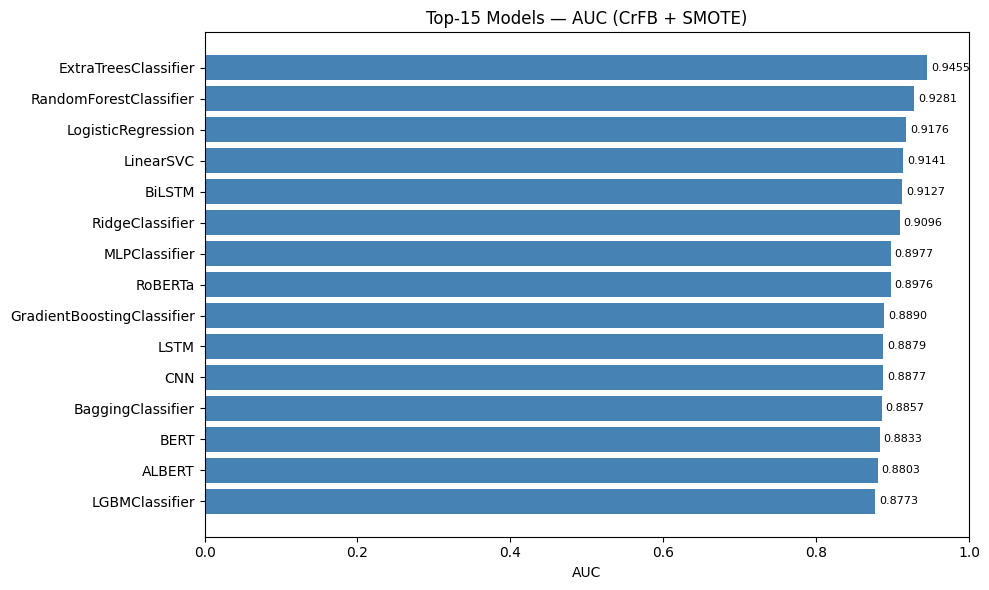

In [ ]:
plot_model_comparison(results_df, metric='AUC', top_n=15)